Realizar Predicciones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "/content/sample_data/"

data_vuelos_nuevos = pd.read_excel("PrediccionesVuelos.xlsx")

vuelos_demorados = data_vuelos_nuevos[data_vuelos_nuevos["demora_predicha"]==1]

print(vuelos_demorados.info())

ids_demorados = vuelos_demorados["id_vuelo"].tolist()


<class 'pandas.DataFrame'>
Index: 2170 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_vuelo                2170 non-null   int64  
 1   aeropuerto_origen       2170 non-null   str    
 2   aeropuerto_destino      2170 non-null   str    
 3   hora_salida_programada  2170 non-null   object 
 4   dia_semana              2170 non-null   str    
 5   distancia_vuelo         2170 non-null   int64  
 6   condiciones_climaticas  2170 non-null   str    
 7   congestion_aerea        2170 non-null   str    
 8   congestion_aerea_num    2170 non-null   int64  
 9   tipo_avion              2170 non-null   str    
 10  ocupacion_vuelo         2170 non-null   float64
 11  temporada_alta          2170 non-null   int64  
 12  puerta_embarque         2170 non-null   int64  
 13  visibilidad             2170 non-null   float64
 14  tiempo_estimado_vuelo   2170 non-null   int64  
 15  hor

In [4]:
data_vuelos_clientes = pd.read_excel("casosNuevos.xlsx",sheet_name="VuelosNuevos_Clientes")

data_vuelos_clientes = data_vuelos_clientes[data_vuelos_clientes["id_vuelo"].isin(ids_demorados)]
id_clientes_demorados = data_vuelos_clientes["id_cliente"].drop_duplicates().tolist()

id_clientes_demorados

[25273,
 22816,
 27405,
 33494,
 26181,
 29645,
 30687,
 32752,
 34127,
 29186,
 12408,
 12525,
 4071,
 3086,
 37973,
 22841,
 31807,
 9999,
 4673,
 33528,
 15394,
 293,
 22906,
 32541,
 7593,
 20826,
 19476,
 26870,
 45864,
 36080,
 43646,
 33887,
 33156,
 1600,
 11049,
 1031,
 13703,
 49096,
 11844,
 8740,
 47240,
 25481,
 12415,
 48838,
 40277,
 14130,
 33153,
 1165,
 20799,
 45314,
 21705,
 26390,
 17032,
 8643,
 3883,
 12470,
 23900,
 15727,
 23081,
 46959,
 19335,
 7064,
 27017,
 1391,
 27640,
 27469,
 45343,
 18349,
 24885,
 9827,
 21024,
 5267,
 13140,
 34217,
 9196,
 38531,
 18833,
 20072,
 44475,
 2450,
 8388,
 2788,
 21907,
 13021,
 20259,
 17585,
 31597,
 29747,
 20766,
 20865,
 23201,
 26748,
 30568,
 7795,
 20558,
 35182,
 41388,
 49138,
 7118,
 17291,
 7546,
 13727,
 31324,
 1414,
 12677,
 28973,
 822,
 44689,
 1064,
 31042,
 22488,
 38035,
 42017,
 8896,
 5534,
 41330,
 4953,
 41442,
 3798,
 41432,
 22177,
 30417,
 4396,
 17709,
 11226,
 33121,
 7647,
 18658,
 834,
 199

# Cluster jerarquico

In [5]:

from scipy.cluster.hierarchy import dendrogram, linkage

data_clientes = pd.read_excel("Clientes.xlsx")
data_clientes = data_clientes[data_clientes["id_cliente"].isin(id_clientes_demorados)]
data_clientes.drop(columns=['id_cliente','provincia','ocupacion','sexo','canal_compra'], inplace=True)

data_clientes['programaMillas'] = data_clientes['programaMillas'].map({'Sí':1,'No':0})

data_clientes['clase_preferida'] = data_clientes['clase_preferida'].map({'Económica':0,'Ejecutiva':1,'Primera clase':2})

data_clientes.info()

<class 'pandas.DataFrame'>
Index: 47703 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   edad                          47703 non-null  int64  
 1   cant_vuelos                   47703 non-null  int64  
 2   clase_preferida               47703 non-null  int64  
 3   gasto_acumulado               47703 non-null  float64
 4   gasto_acumulado_extra         47703 non-null  float64
 5   programaMillas                47703 non-null  int64  
 6   cantidad_millas               47703 non-null  int64  
 7   ingreso_mensual               47703 non-null  int64  
 8   anticipacion_compra_promedio  47703 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.6 MB


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_Z = pd.DataFrame(scaler.fit_transform(data_clientes))

In [7]:
Z = linkage(df_Z, 'centroid')

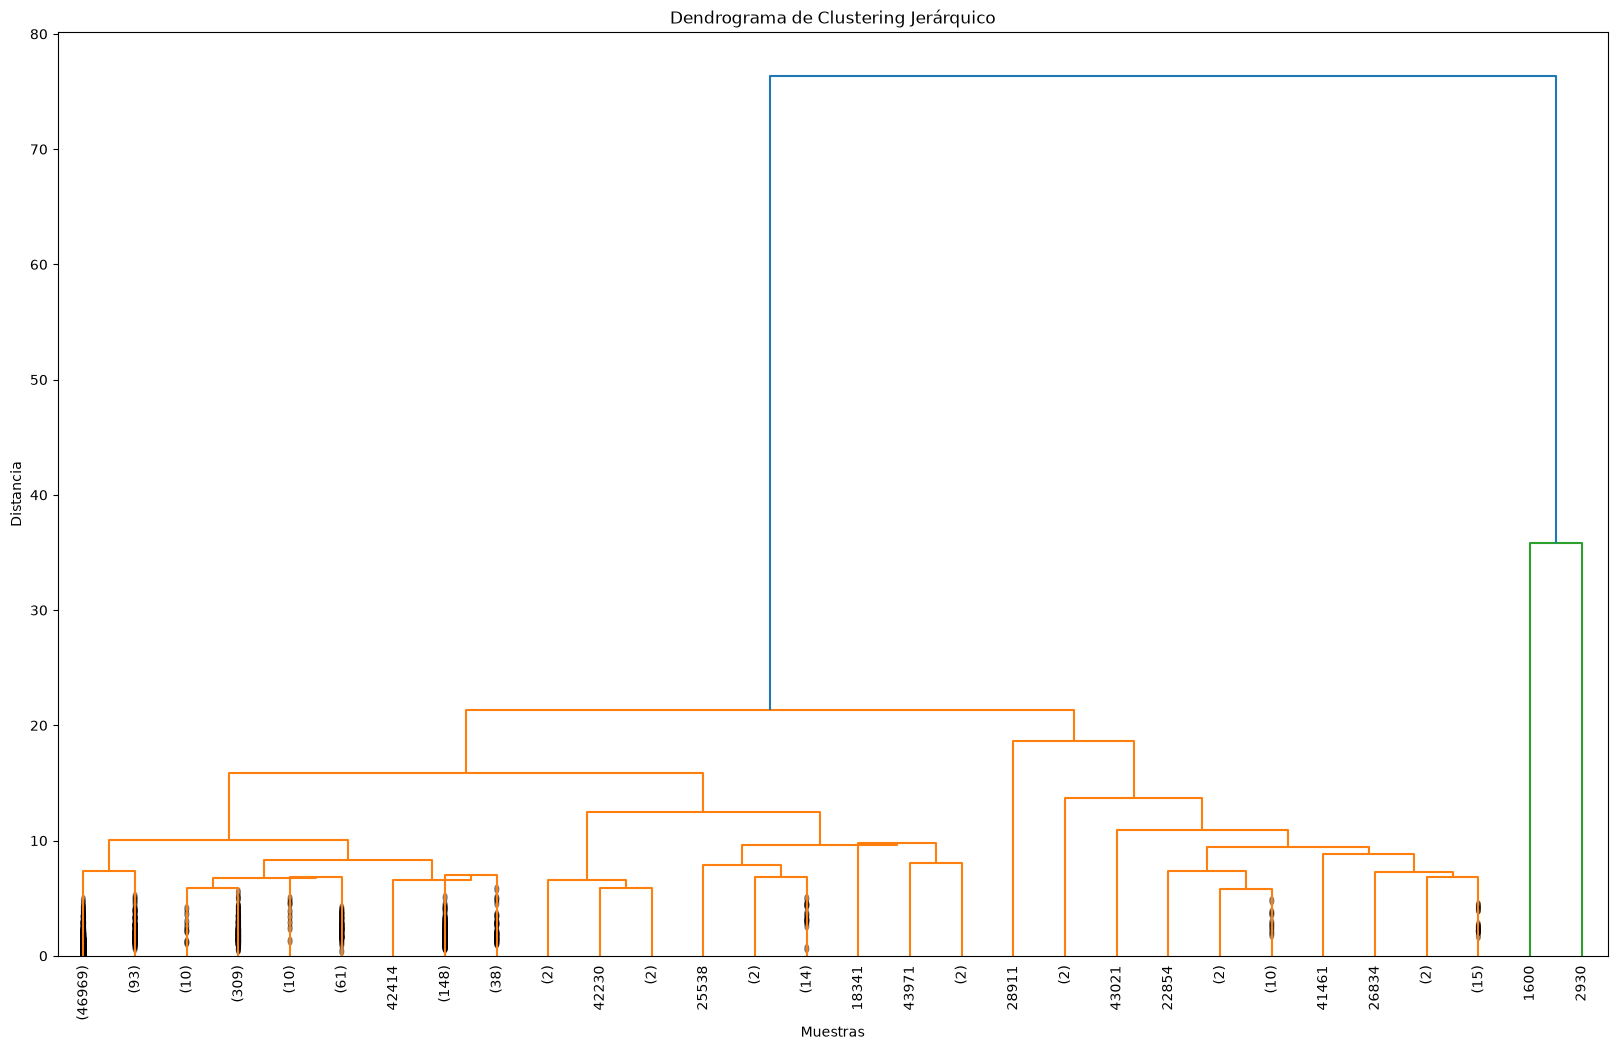

In [8]:
plt.figure(figsize=(20, 12))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

In [9]:
Z = linkage(df_Z, 'ward')

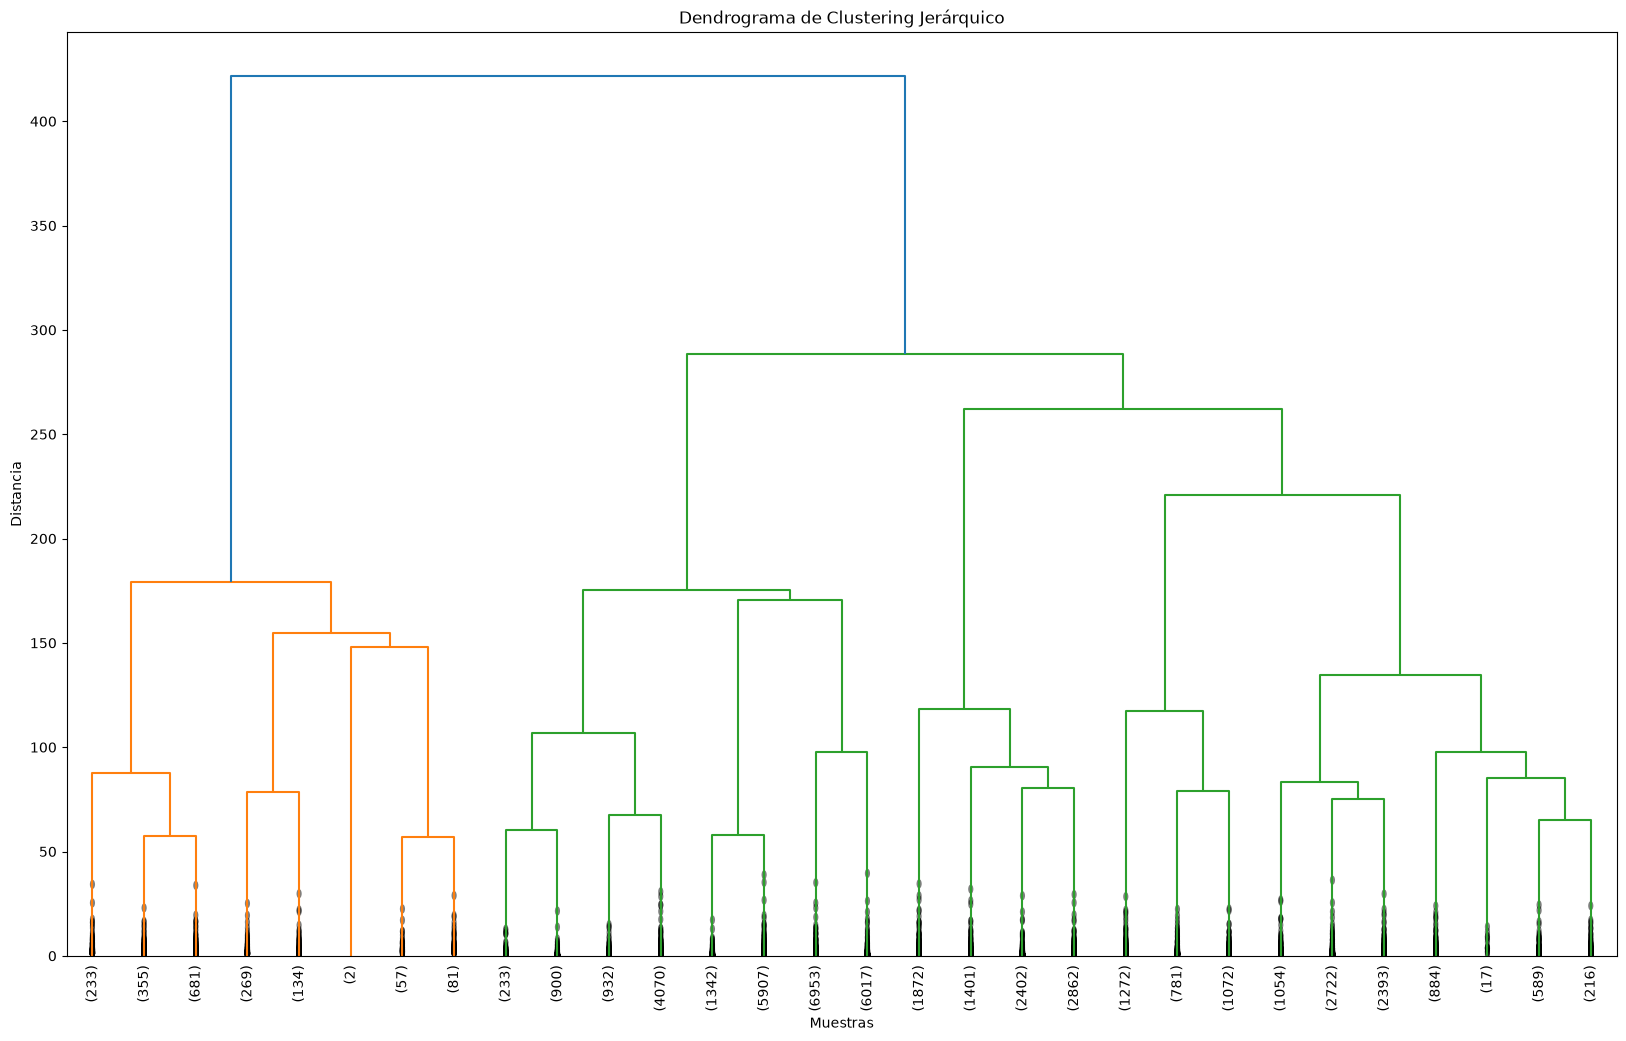

In [10]:
plt.figure(figsize=(20, 12))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

In [11]:
Z = linkage(df_Z, 'single')

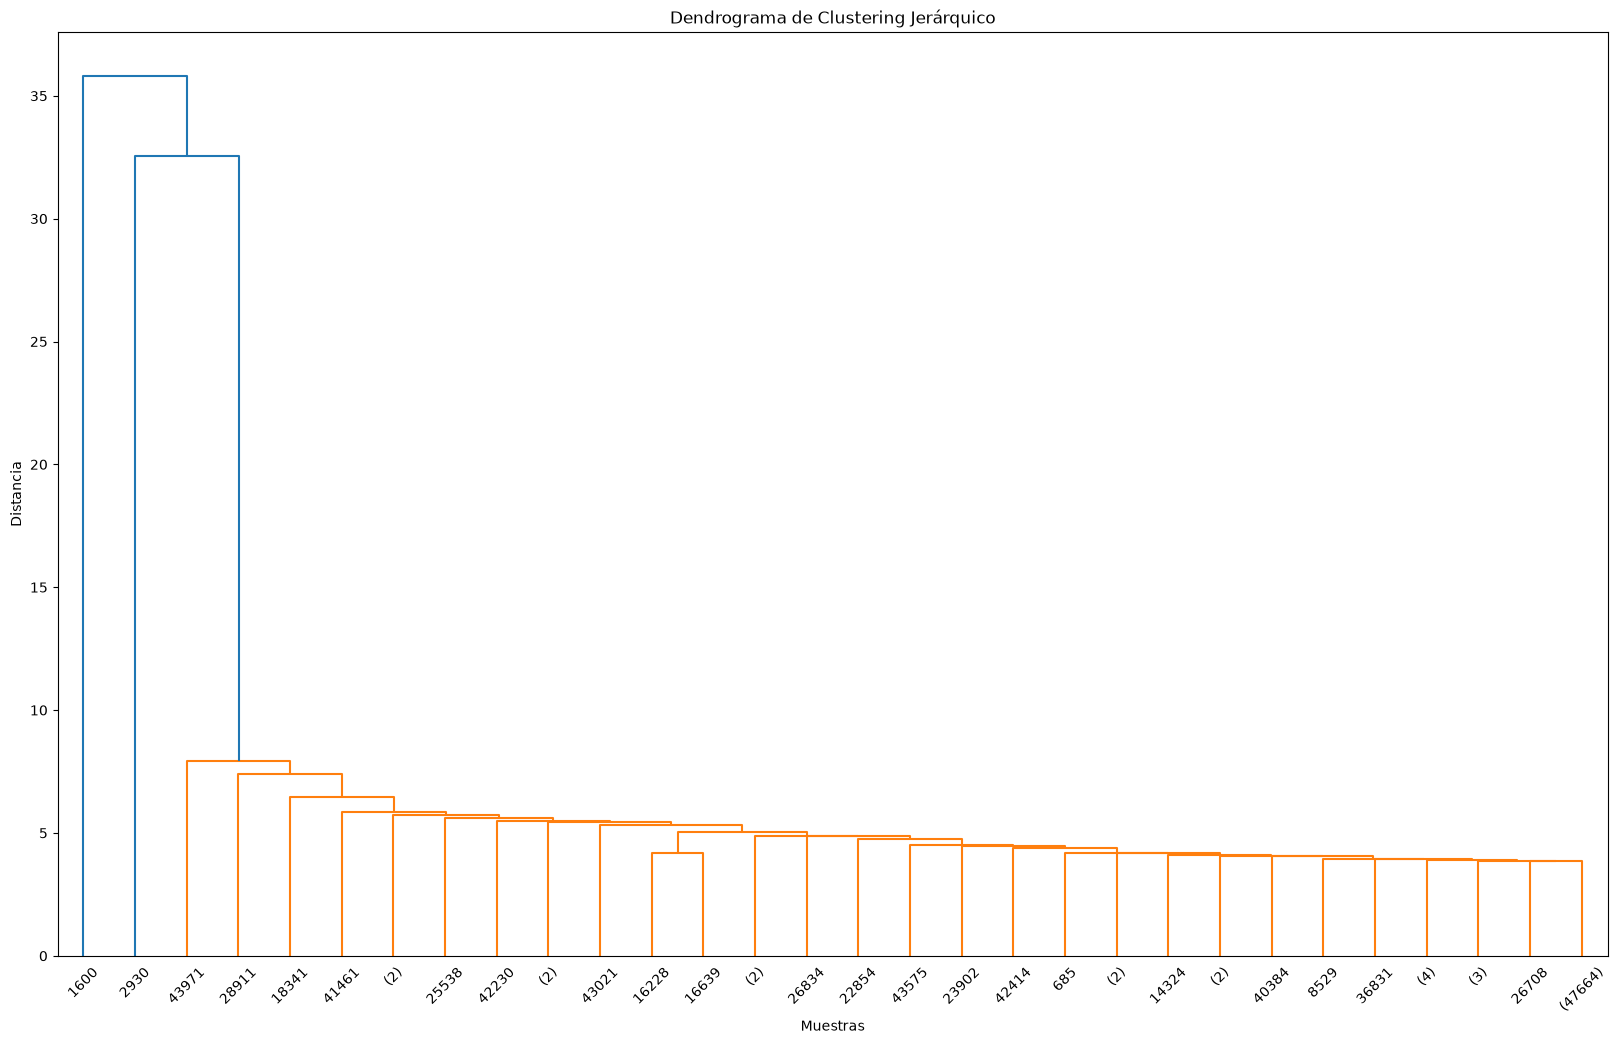

In [13]:
import sys

sys.setrecursionlimit(10000)


plt.figure(figsize=(20, 12))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

In [14]:
Z = linkage(df_Z, 'complete')

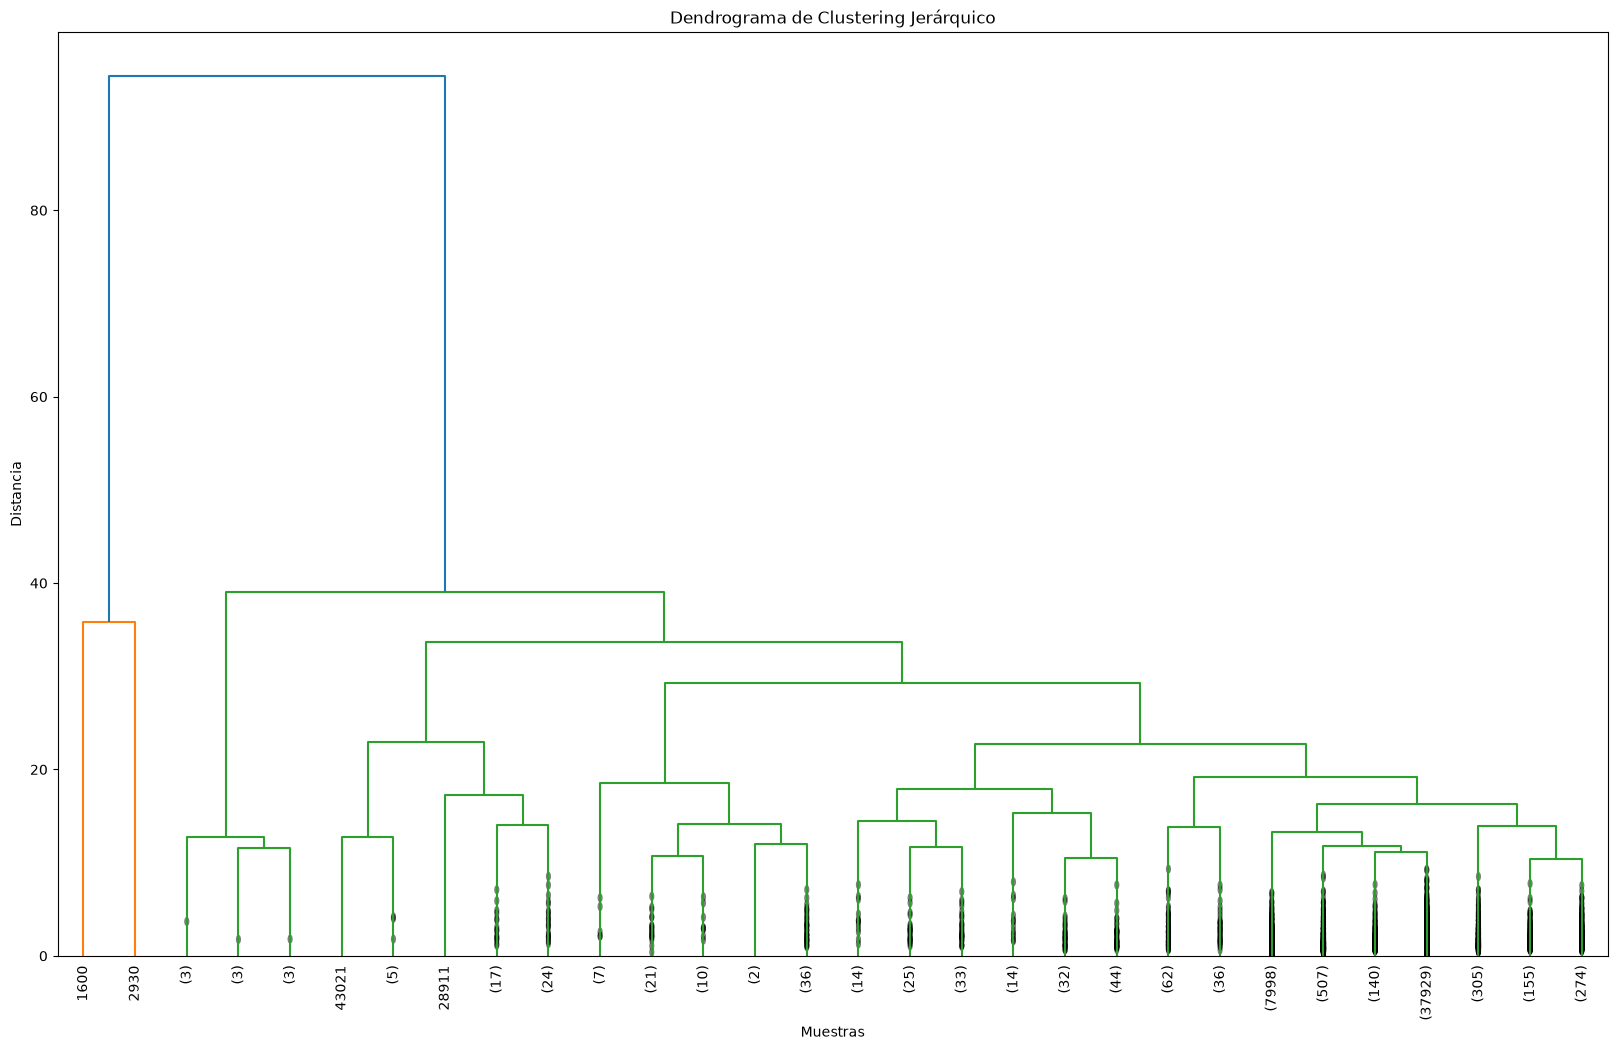

In [15]:
plt.figure(figsize=(20, 12))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

In [16]:
Z = linkage(df_Z, 'average')

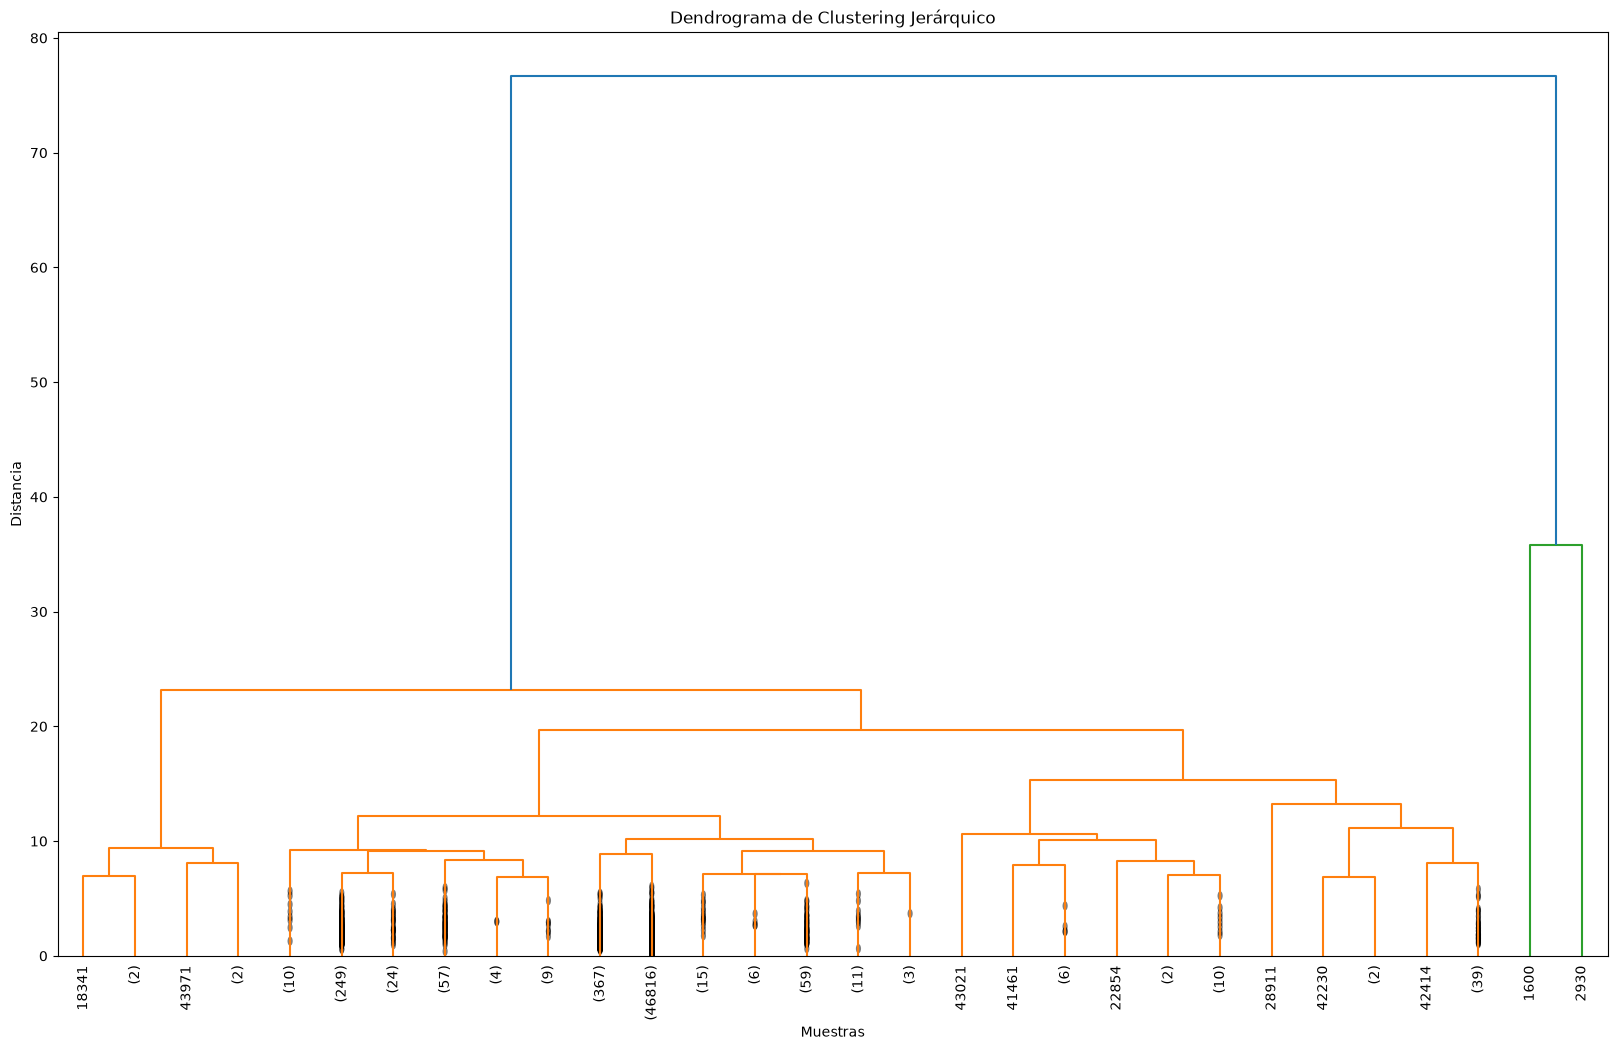

In [17]:
plt.figure(figsize=(20, 12))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

Clustering No Jerarquico

In [ ]:
data_clientes = pd.read_excel(ruta+"Clientes.xlsx")
data_clientes = data_clientes[data_clientes["id_cliente"].isin(ids_demorados)]
data_clientes.drop(columns=['id_cliente','provincia','ocupacion','sexo','canal_compra'], inplace=True)

data_clientes['programaMillas'] = data_clientes['programaMillas'].map({'Sí':1,'No':0})

data_clientes['clase_preferida'] = data_clientes['clase_preferida'].map({'Económica':0,'Ejecutiva':1,'Primera clase':2})

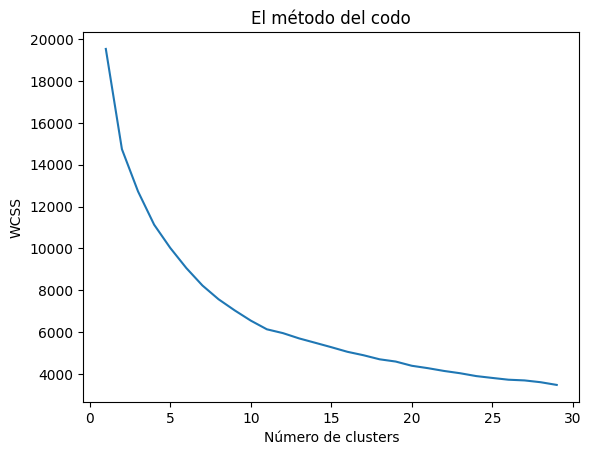

In [ ]:
from sklearn.cluster import KMeans

scaler = StandardScaler()

data_clientes = scaler.fit_transform(data_clientes)

wcss = []

for i in range(1, 30):
    kmeans = KMeans(n_clusters=i,n_init=17, random_state=0)
    kmeans.fit(data_clientes)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 30), wcss)
plt.title('El método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

Para K = 5, el puntaje de silueta promedio es: 0.210


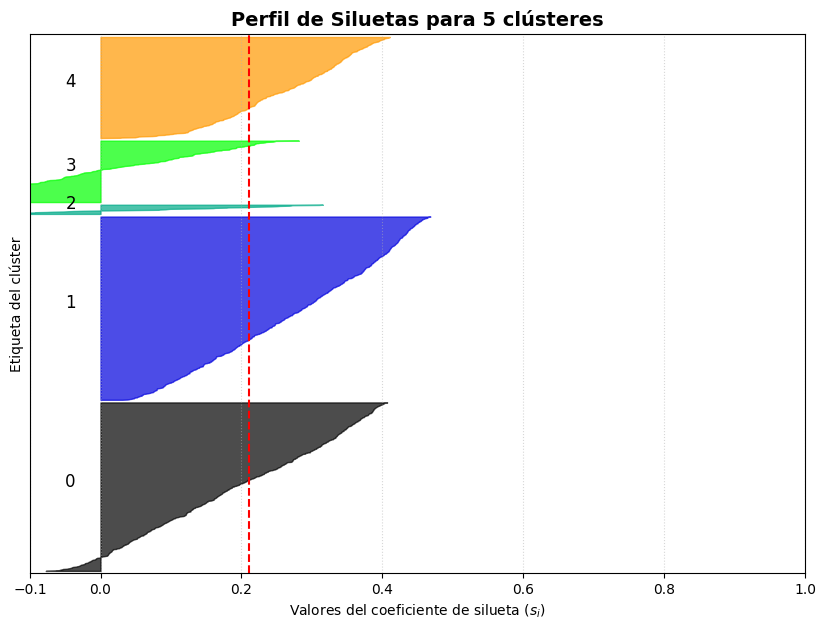

Para K = 6, el puntaje de silueta promedio es: 0.293


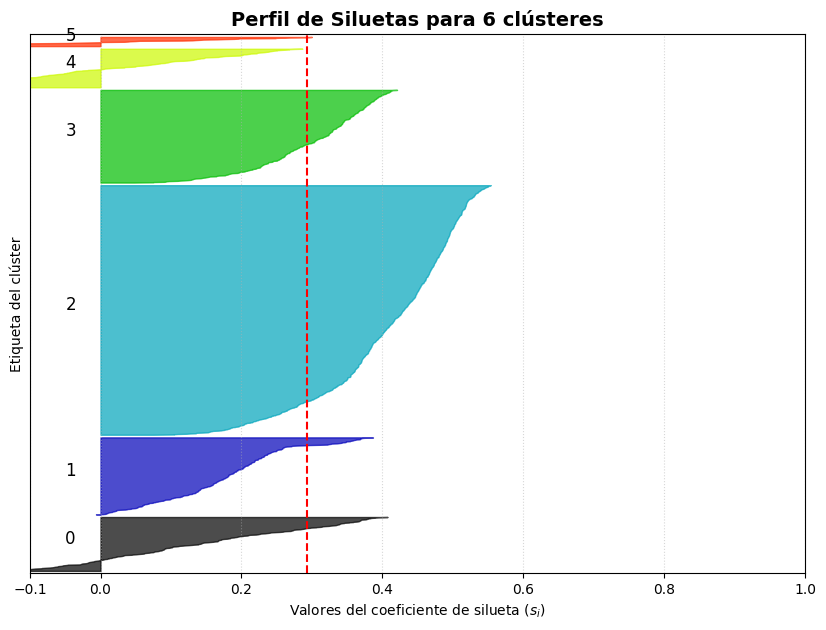

Para K = 7, el puntaje de silueta promedio es: 0.240


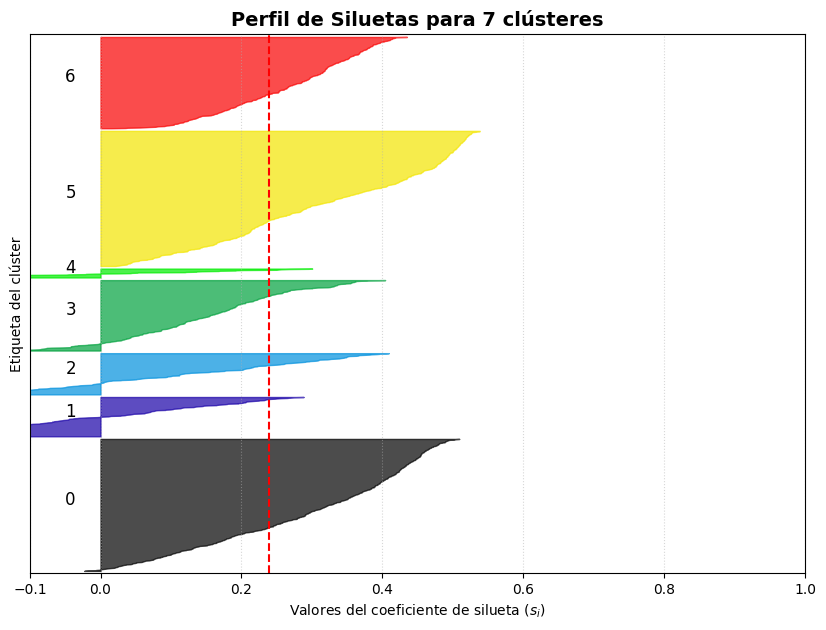

Para K = 8, el puntaje de silueta promedio es: 0.241


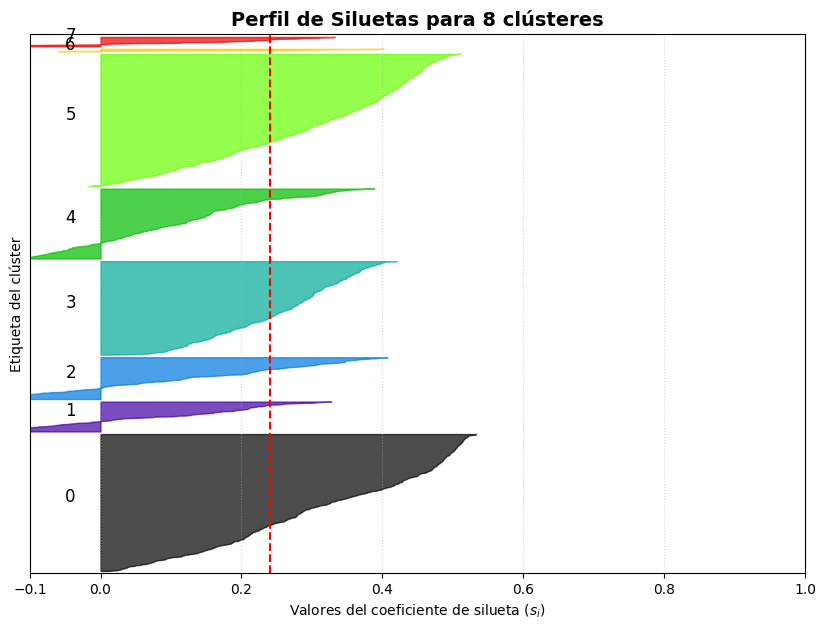

Para K = 9, el puntaje de silueta promedio es: 0.250


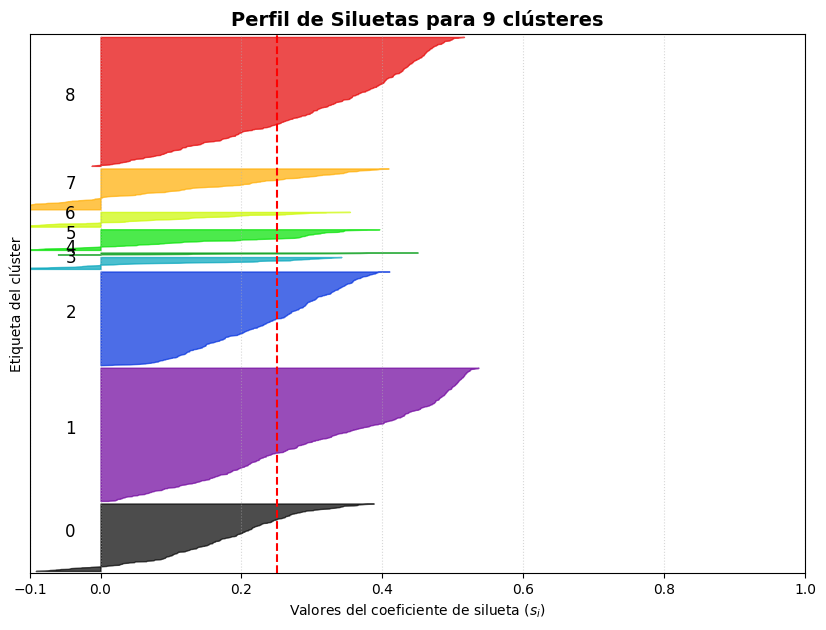

Para K = 10, el puntaje de silueta promedio es: 0.251


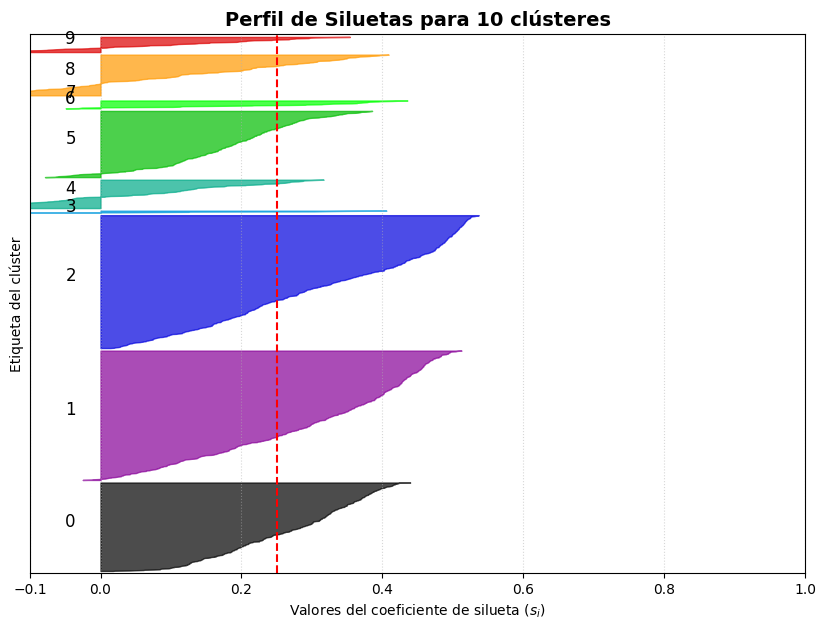

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Rango de clústeres a evaluar
rango_n_clusters = [5, 6, 7, 8, 9, 10]

for n_clusters in rango_n_clusters:
    # Crear la figura con un solo panel
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)

    # Configurar los límites del gráfico
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(df_Z) + (n_clusters + 1) * 10])

    # 1. Ejecutar K-Means
    clusterer = KMeans(n_clusters=n_clusters, n_init=17, random_state=0)
    cluster_labels = clusterer.fit_predict(df_Z)

    # 2. Calcular los puntajes de silueta
    silhouette_avg = silhouette_score(df_Z, cluster_labels)
    print(f"Para K = {n_clusters}, el puntaje de silueta promedio es: {silhouette_avg:.3f}")
    sample_silhouette_values = silhouette_samples(df_Z, cluster_labels)

    y_lower = 10

    # 3. Dibujar el perfil de cada clúster
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        # Asignar un color distinto a cada clúster
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
            facecolor=color, edgecolor=color, alpha=0.7,
        )

        # Poner el número del clúster a la izquierda
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
        y_lower = y_upper + 10

    # --- Detalles visuales finales ---
    ax1.set_title(f"Perfil de Siluetas para {n_clusters} clústeres", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Valores del coeficiente de silueta ($s_i$)")
    ax1.set_ylabel("Etiqueta del clúster")

    # Dibujar la línea roja del promedio
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Limpiar y ajustar los ejes
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.grid(True, axis='x', linestyle=':', alpha=0.5)

    # Mostrar este gráfico antes de pasar al siguiente K en el bucle
    plt.show()

Componentes Principales

In [ ]:
from sklearn.preprocessing import StandardScaler

data_clientes = pd.read_excel(ruta+"Clientes.xlsx")
data_clientes = data_clientes[data_clientes["id_cliente"].isin(ids_demorados)]
data_clientes.drop(columns=['id_cliente','provincia','ocupacion','sexo','canal_compra'], inplace=True)

data_clientes['programaMillas'] = data_clientes['programaMillas'].map({'Sí':1,'No':0})

data_clientes['clase_preferida'] = data_clientes['clase_preferida'].map({'Económica':0,'Ejecutiva':1,'Primera clase':2})

scaler = StandardScaler()
df_scaled = scaler.fit_transform(data_clientes)

from sklearn.decomposition import PCA

pca = PCA(n_components=9)

# Ajustamos el modelo a los datos.
pca.fit(df_scaled)

# Transformamos los datos.
df_pca = pca.transform(df_scaled)

# Convertimos los datos transformados en un DataFrame de Pandas.
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6','PC7', 'PC8','PC9'])

# Mostramos las primeras filas del DataFrame.
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-1.220902,-0.351786,-0.890206,-1.334914,-0.025514,0.442098,0.348132,-0.182893,0.048782
1,-1.344768,0.033126,0.801389,-0.547950,-0.039554,-0.448627,0.530847,-0.295400,0.001290
2,-0.818580,1.614995,-0.404452,-0.430288,0.571449,-0.611130,-0.551443,-0.514625,0.010428
3,0.307719,1.895576,0.708962,0.724990,0.128937,-0.176576,-0.692524,-0.149875,-0.000793
4,0.298567,2.220034,1.096452,0.685779,0.146033,-0.515345,-0.271079,-0.018621,-0.026686


In [ ]:
pca.explained_variance_ratio_

array([0.40918066, 0.12985679, 0.11818307, 0.10340169, 0.08605214,
       0.07004825, 0.04020828, 0.03451043, 0.0085587 ])

In [ ]:
loadings = pca.components_.T  # Transponer para alinear con las variables originales en las filas

features = ['X1', 'X2', 'X3','X4', 'X5', 'X6','X7', 'X8', 'X9', ]

# Crear el DataFrame de cargas
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=features)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
X1,0.075047,0.112894,0.691464,0.680010,-0.006778,-0.199063,0.022022,-0.030414,0.002100
X2,0.385749,0.142143,0.087056,-0.009113,-0.488326,0.390365,-0.327705,0.568971,-0.036952
X3,0.329374,-0.410884,-0.031946,-0.021293,0.516702,-0.406371,-0.158536,0.512563,-0.035220
X4,0.468479,-0.190151,-0.034956,-0.057179,-0.240670,-0.188579,-0.072497,-0.337454,0.726129
X5,0.462691,-0.191490,-0.047962,-0.045405,-0.256240,-0.195763,-0.038740,-0.411687,-0.685506
X6,0.183242,0.734265,-0.251031,0.063081,0.288424,-0.210111,-0.461133,-0.142425,-0.004259
X7,0.394354,0.357049,-0.164402,0.034961,0.041199,-0.043045,0.803805,0.197552,0.008448
X8,0.332813,-0.115782,0.107478,0.076999,0.524829,0.716594,-0.017164,-0.262863,0.002375
X9,-0.060540,-0.212989,-0.638874,0.721518,-0.102949,0.097266,-0.034556,0.029259,0.010630


In [ ]:
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza': pca.explained_variance_})
df_varianza

,Componente,Varianza
0,1,3.684324
1,2,1.169250
2,3,1.064138
3,4,0.931044
4,5,0.774826
5,6,0.630725
6,7,0.362041
7,8,0.310737
8,9,0.077064


In [ ]:
df_varianza_ratio = pd.DataFrame(data={'Componente': range(1, 10), '% Varianza explicada': pca.explained_variance_ratio_})
df_varianza_ratio

,Componente,% Varianza explicada
0,1,0.409181
1,2,0.129857
2,3,0.118183
3,4,0.103402
4,5,0.086052
5,6,0.070048
6,7,0.040208
7,8,0.034510
8,9,0.008559


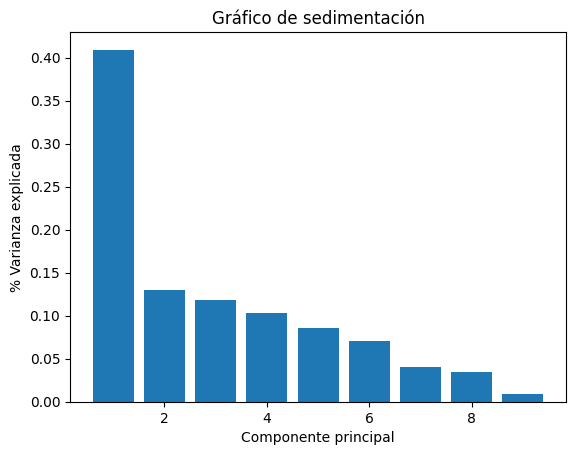

In [ ]:
# Creamos un DataFrame con la varianza explicada por cada componente principal.
df_varianza = pd.DataFrame(data={'Componente': range(1, 10), 'Varianza explicada': pca.explained_variance_ratio_})

# Creamos un gráfico de barras.
plt.bar(df_varianza['Componente'], df_varianza['Varianza explicada'])

# Añadimos etiquetas y título al gráfico.
plt.xlabel('Componente principal')
plt.ylabel('% Varianza explicada')
plt.title('Gráfico de sedimentación')

# Mostramos el gráfico.
plt.show()
